## Logistic Regression

**Logistic Regression** is a supervised machine learning algorithm used for classification problems. It predicts the probability that an observation belongs to a specific class.

Unlike linear regression, which predicts continuous values, logistic regression predicts categorical outcomes such as yes/no, true/false, or disease/no disease.

---

### Common Applications

- Spam detection  
- Disease diagnosis  
- Credit risk prediction  
- Fraud detection  
- Customer churn prediction  

---

### Why Logistic Regression is Needed

In many real-world problems, the target variable is categorical. Linear regression is not suitable because its output can be less than 0 or greater than 1, which is not meaningful for probability.

Logistic regression solves this problem by transforming the output into a probability value between 0 and 1 using the sigmoid function.

---

## Sigmoid Function (Logistic Function)

The sigmoid function converts any real-valued number into a value between 0 and 1, making it suitable for probability estimation.

$ \sigma(z) = \frac{1}{1 + e^{-z}} $ where $ z = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_n X_n $

---

### Why the Sigmoid Function is Used

- Linear model output can range from $-\infty$ to $+\infty$  
- Probabilities must lie between 0 and 1  
- The sigmoid function transforms linear output into a valid probability  

---

### Behavior of the Sigmoid Function

| z value | Output | Meaning |
|--------|--------|--------|
| large negative | close to 0 | strong negative class |
| 0 | 0.5 | uncertain |
| large positive | close to 1 | strong positive class |

The sigmoid curve is S-shaped, providing a smooth transition between classes.

---

### Example

If $ z = 2 $, $ \sigma(2) \approx 0.88 $ -> Probability $\approx 88\%$ → Class 1

---

## Logistic Regression Model

### Step 1: Linear Combination

$$
z = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_n X_n
$$

### Step 2: Apply Sigmoid Function

$$
P(Y=1) = \frac{1}{1 + e^{-z}}
$$

This gives the probability of belonging to class 1.

---

## How Logistic Regression Works

1. Calculate weighted sum of input variables.  
2. Apply sigmoid function to obtain probability.  
3. Compare probability with a threshold (default = 0.5).  
4. Assign class label.  

Example:

- Probability = 0.75 → Class 1  
- Probability = 0.20 → Class 0  

---

## Odds and Log-Odds (Logit Function)

Logistic regression models the log-odds of the outcome.

$$
Odds = \frac{P}{1-P}
$$

$$
Logit(P) = \ln\left(\frac{P}{1-P}\right)
$$

This transformation allows probabilities to be modeled using a linear equation.

---

## Types of Logistic Regression

**Binary Logistic Regression**
Used when the dependent variable has two classes. (sigmoid function)

**Multinomial Logistic Regression**   
Used for more than two unordered classes. (softmax function)  

**Ordinal Logistic Regression**  
Used for ordered categories. (Cumulative Logit (Proportional Odds) function)

---

## Assumptions of Logistic Regression

- The dependent variable is categorical.  
- Observations are independent.  
- Predictors are not highly correlated (no multicollinearity).  
- There is a linear relationship between predictors and log-odds.  
- A large sample size improves reliability.  

---

## Interpretation of Coefficients

Logistic regression coefficients represent changes in log-odds.

To interpret them easily, convert to odds ratios:

$$
Odds\ Ratio = e^{\beta}
$$

**Interpretation:**

- $OR > 1$ → increases likelihood of outcome  
- $OR < 1$ → decreases likelihood  
- $OR = 1$ → no effect  

---

## Model Evaluation Metrics

Since logistic regression is used for classification:

- Confusion Matrix → prediction performance  
- Accuracy → overall correctness  
- Precision → correctness of positive predictions  
- Recall (Sensitivity) → ability to detect positives  
- F1 Score → balance between precision & recall  
- ROC Curve & AUC → discrimination ability  

AUC Interpretation:

- 0.5 → random  
- 0.7-0.8 → good  
- 0.8-0.9 → very good  
- $>$ 0.9 → excellent  

---

## Advantages

- Simple and easy to interpret  
- Provides probability outputs  
- Computationally efficient  
- Works well with linearly separable data  
- Coefficients are interpretable  

---

## Limitations

- Cannot capture complex nonlinear relationships  
- Sensitive to multicollinearity  
- Assumes linearity in log-odds  
- May struggle with highly imbalanced data  

---

## Logistic vs Linear Regression

| Feature | Linear Regression | Logistic Regression |
|--------|------------------|-------------------|
| Output | Continuous | Categorical |
| Range | $(-\infty, +\infty)$ | 0 to 1 |
| Function | Straight line | Sigmoid curve |
| Purpose | Prediction | Classification |

---

## Final Summary

Logistic regression predicts the probability of class membership by applying a sigmoid transformation to a linear combination of predictors, enabling accurate and interpretable classification.

In [141]:
# ============================================================
# Importing essential libraries for data analysis and modeling
# ============================================================

import numpy as np                # Numerical computing and array operations
import pandas as pd               # Data manipulation and DataFrame handling
import matplotlib.pyplot as plt   # Data visualization (plots and charts)
import seaborn as sns             # Statistical data visualization

from sklearn.model_selection import train_test_split  # Split data into training and testing sets
from sklearn.linear_model import LogisticRegression     # Linear Regression model

from sklearn.metrics import *     # Model evaluation metrics (e.g., R², MAE, MSE, RMSE)

from sklearn.preprocessing import LabelEncoder        # Encode categorical labels into numeric form

In [142]:
import warnings
warnings.filterwarnings('ignore')

In [143]:
url = "https://drive.google.com/uc?export=download&id=15OoO-FrY0mC58XYMWidKxMSwf1admEh_"
df = pd.read_csv(url)
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


The above dataset contains of past customers data given by a bank. Bank officials a new scheme based on the past data. we have to predict whether a person is going to be interested in the scheme or not.

In [144]:
df.isnull().sum().sum()

np.int64(0)

No null values.

- Lets Predict if we have null vaues
- if we have enough data the we can drop ---> df.dropna(inplace=True)
- If there is data scarity ---> Replace them with mean(numerical) or mode(categorical)

- if col in df.columns:
-     if df[col].dtype!='object':
-         df[col].fillna(df[col].mean(),inplace=True)
-     else:
-         df[col].fillna(df[col].mode()[0],inplace=True)

In [145]:
df['y'].replace({'yes': 1, 'no': 0}, inplace=True)
df['y'].groupby(df['y']).count()

,y
y,
0,36548
1,4640


In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  campaign        41188 non-null  int64  
 11  pdays           41188 non-null  int64  
 12  previous        41188 non-null  int64  
 13  poutcome        41188 non-null  object 
 14  emp.var.rate    41188 non-null  float64
 15  cons.price.idx  41188 non-null  float64
 16  cons.conf.idx   41188 non-null  float64
 17  euribor3m       41188 non-null 

In [147]:
# EDA : Exploratory data analysis

In [148]:
# Duplicate value
df.duplicated().sum()

np.int64(1784)

In [149]:
df.drop_duplicates(inplace=True)

In [150]:
df.duplicated().sum()

np.int64(0)

In [151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39404 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             39404 non-null  int64  
 1   job             39404 non-null  object 
 2   marital         39404 non-null  object 
 3   education       39404 non-null  object 
 4   default         39404 non-null  object 
 5   housing         39404 non-null  object 
 6   loan            39404 non-null  object 
 7   contact         39404 non-null  object 
 8   month           39404 non-null  object 
 9   day_of_week     39404 non-null  object 
 10  campaign        39404 non-null  int64  
 11  pdays           39404 non-null  int64  
 12  previous        39404 non-null  int64  
 13  poutcome        39404 non-null  object 
 14  emp.var.rate    39404 non-null  float64
 15  cons.price.idx  39404 non-null  float64
 16  cons.conf.idx   39404 non-null  float64
 17  euribor3m       39404 non-null  floa

In [152]:
df.shape

(39404, 20)

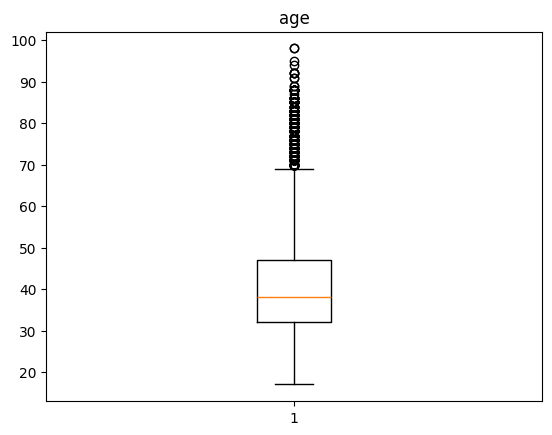

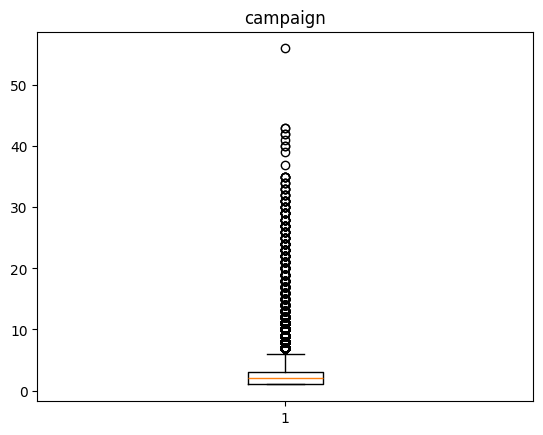

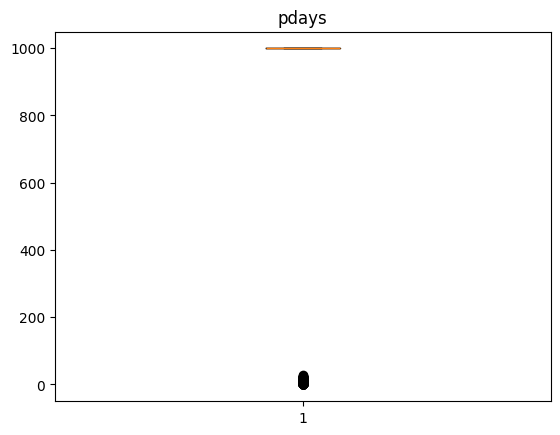

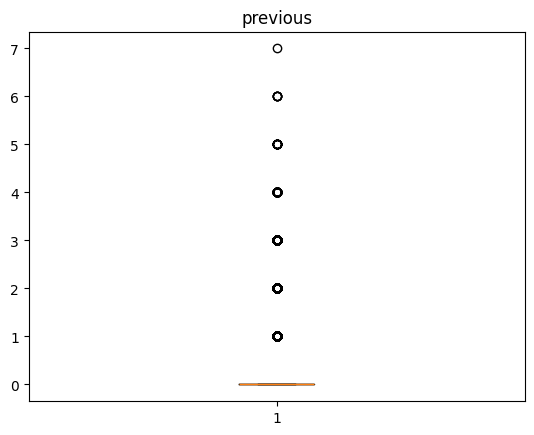

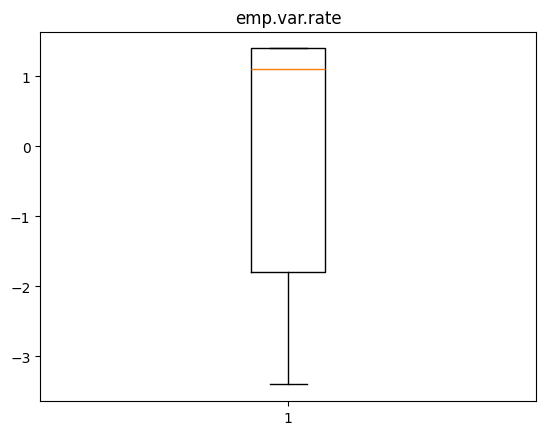

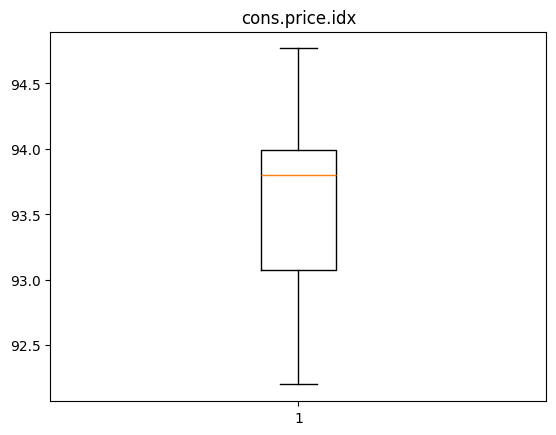

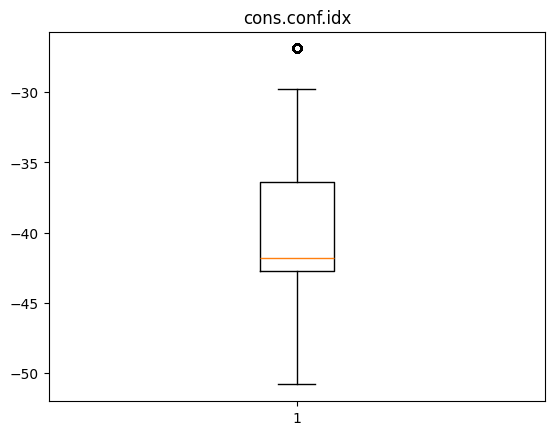

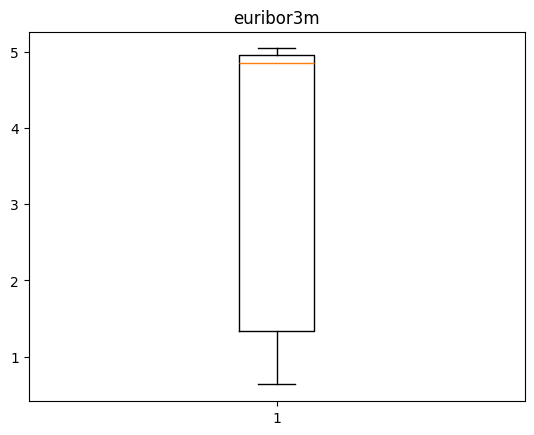

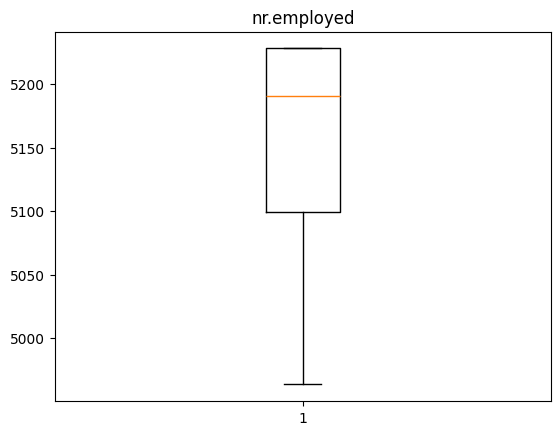

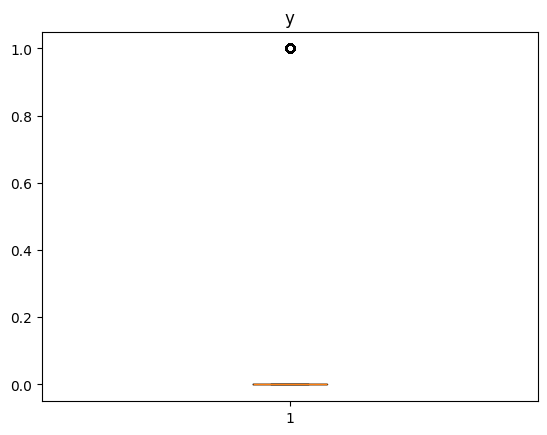

In [153]:
# outlier

for col in df.columns:
    if df[col].dtype != 'object':
        plt.boxplot(df[col])
        plt.title(col)
        plt.show()

In [154]:
df['pdays'].value_counts()

,count
pdays,
999,37890
3,438
6,412
4,118
9,64
2,61
7,60
12,58
10,52


In [155]:
out_col=['age','campaign','cons.conf.idx']

for col in out_col:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)

    IQR=Q3-Q1

    LB=Q1-1.5*IQR
    UB=Q3+1.5*IQR

    df=df[(df[col]<=UB)&(df[col]>=LB)]


In [156]:
df.shape

(36178, 20)

In [157]:
df.select_dtypes(include='object')

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome
0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,nonexistent
1,services,married,high.school,unknown,no,no,telephone,may,mon,nonexistent
2,services,married,high.school,no,yes,no,telephone,may,mon,nonexistent
3,admin.,married,basic.6y,no,no,no,telephone,may,mon,nonexistent
4,services,married,high.school,no,no,yes,telephone,may,mon,nonexistent
...,...,...,...,...,...,...,...,...,...,...
41181,admin.,married,university.degree,no,yes,no,cellular,nov,fri,nonexistent
41182,unemployed,single,basic.4y,no,yes,no,cellular,nov,fri,success
41184,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,nonexistent
41185,retired,married,university.degree,no,yes,no,cellular,nov,fri,nonexistent


In [158]:
# Label Encodeing for Categorical data into numerical
Le=LabelEncoder()

for col in df.columns:
    if df[col].dtype=='object':
        df[col]=Le.fit_transform(df[col])



In [159]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36178 entries, 0 to 41186
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             36178 non-null  int64  
 1   job             36178 non-null  int64  
 2   marital         36178 non-null  int64  
 3   education       36178 non-null  int64  
 4   default         36178 non-null  int64  
 5   housing         36178 non-null  int64  
 6   loan            36178 non-null  int64  
 7   contact         36178 non-null  int64  
 8   month           36178 non-null  int64  
 9   day_of_week     36178 non-null  int64  
 10  campaign        36178 non-null  int64  
 11  pdays           36178 non-null  int64  
 12  previous        36178 non-null  int64  
 13  poutcome        36178 non-null  int64  
 14  emp.var.rate    36178 non-null  float64
 15  cons.price.idx  36178 non-null  float64
 16  cons.conf.idx   36178 non-null  float64
 17  euribor3m       36178 non-null  floa

In [160]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,1,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,2,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,2,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41181,37,0,1,6,0,2,0,0,7,0,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,1
41182,29,10,2,0,0,2,0,0,7,0,1,9,1,2,-1.1,94.767,-50.8,1.028,4963.6,0
41184,46,1,1,5,0,0,0,0,7,0,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,0
41185,56,5,1,6,0,2,0,0,7,0,2,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,0


In [162]:
# Correlation: relationship between 2 numerical variable- how one change when other change

CorMat=df.corr()
CorMat

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
age,1.000000,-0.018506,-0.388425,-0.097211,0.188718,-0.001729,-0.009060,0.029388,-0.036293,-0.025109,0.005962,0.007390,-0.025933,0.019295,0.075228,0.037307,0.103288,0.086735,0.072747,-0.022390
job,-0.018506,1.000000,0.037164,0.142671,-0.026630,0.006002,-0.010860,-0.023837,-0.032415,-0.001641,-0.009357,-0.026749,0.019729,0.010517,-0.002252,-0.010256,0.046091,-0.002354,-0.012999,0.019792
marital,-0.388425,0.037164,1.000000,0.104102,-0.079582,0.009767,0.007514,-0.058513,-0.008818,0.005343,-0.008823,-0.051401,0.051673,0.004388,-0.101943,-0.060699,-0.033939,-0.110612,-0.110196,0.058802
education,-0.097211,0.142671,0.104102,1.000000,-0.192025,0.014668,0.005004,-0.108438,-0.081262,-0.019656,-0.002219,-0.060958,0.050608,0.020244,-0.062420,-0.085735,0.083066,-0.055083,-0.065208,0.071045
default,0.188718,-0.026630,-0.079582,-0.192025,1.000000,-0.016202,-0.004329,0.134633,-0.010791,-0.006992,0.026083,0.084148,-0.105211,0.021705,0.202589,0.159868,0.046232,0.194718,0.190468,-0.099809
housing,-0.001729,0.006002,0.009767,0.014668,-0.016202,1.000000,0.046522,-0.080323,-0.020244,-0.001833,-0.007063,-0.011997,0.024950,-0.012626,-0.062627,-0.081238,-0.034464,-0.060621,-0.047404,0.012587
loan,-0.009060,-0.010860,0.007514,0.005004,-0.004329,0.046522,1.000000,-0.013360,-0.007946,-0.007160,0.004584,0.003474,-0.005205,-0.000405,0.005342,-0.003723,-0.009031,0.003755,0.007860,-0.007853
contact,0.029388,-0.023837,-0.058513,-0.108438,0.134633,-0.080323,-0.013360,1.000000,0.285346,-0.005089,0.033025,0.120477,-0.221583,0.126426,0.411964,0.603740,0.299958,0.415225,0.279048,-0.148016
month,-0.036293,-0.032415,-0.008818,-0.081262,-0.010791,-0.020244,-0.007946,0.285346,1.000000,0.035691,-0.043945,-0.033845,0.088171,-0.062412,-0.124333,0.037617,-0.030525,-0.069672,-0.173646,-0.028549
day_of_week,-0.025109,-0.001641,0.005343,-0.019656,-0.006992,-0.001833,-0.007160,-0.005089,0.035691,1.000000,-0.049757,-0.011359,-0.003125,0.018630,0.035314,0.008291,0.045487,0.041011,0.029958,0.016365


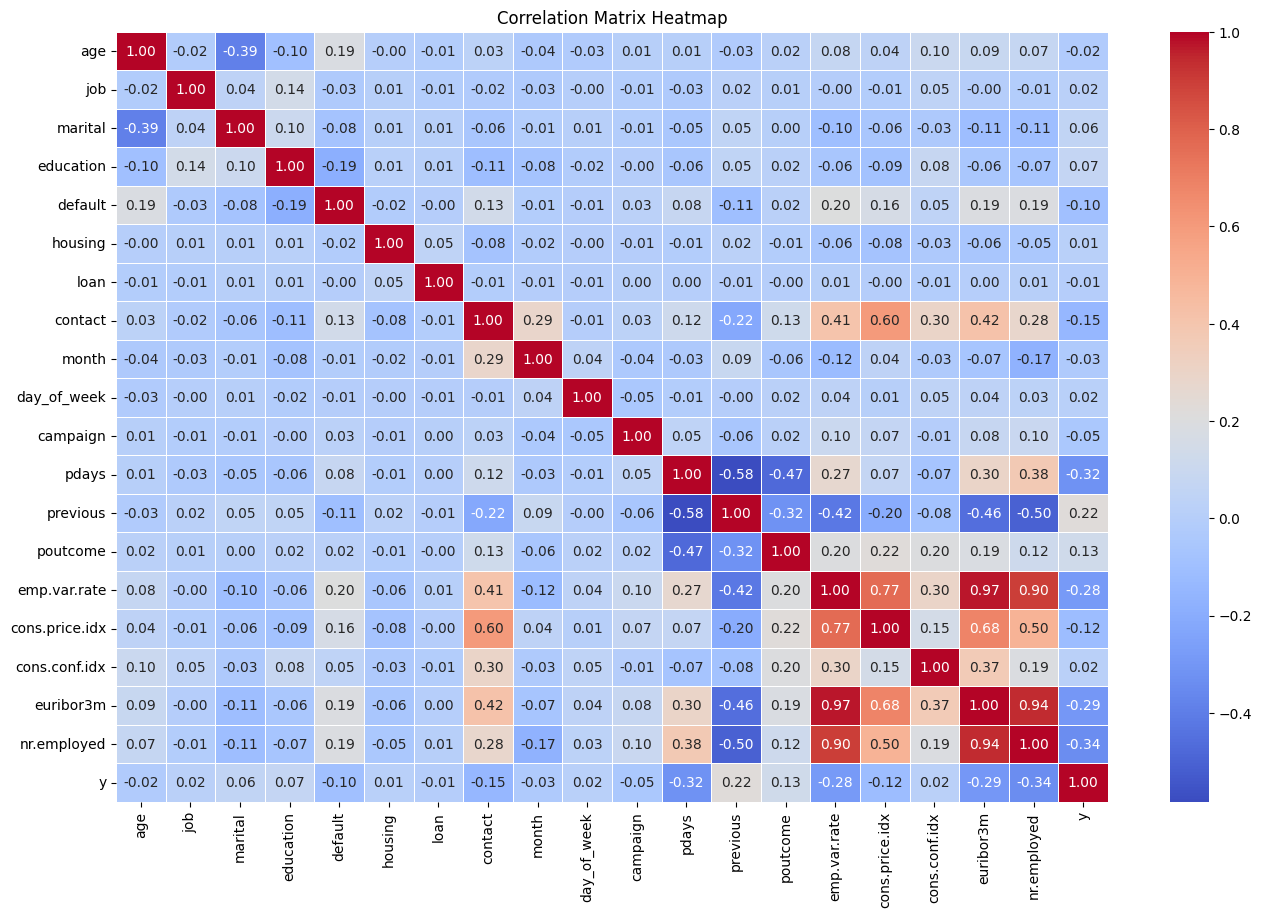

In [163]:
plt.figure(figsize=(16, 10))
sns.heatmap(CorMat, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

## Multicollinearity Detection using VIF

In regression models, highly correlated independent variables can cause **multicollinearity**, which leads to unstable coefficient estimates and unreliable model interpretation.

To detect multicollinearity we use **Variance Inflation Factor (VIF)**.

The VIF value measures how much the variance of a regression coefficient is inflated due to correlation with other predictors.

VIF is calculated as

$
VIF_i = \frac{1}{1-R_i^2}
$

where $R_i^2$ is the coefficient of determination obtained when the $i^{th}$ predictor is regressed on all other predictors.

### Interpretation of VIF

| VIF Value | Interpretation |
|----------|---------------|
| VIF = 1 | No multicollinearity |
| 1 < VIF < 5 | Moderate correlation |
| VIF > 5 | Potential multicollinearity |
| VIF > 10 | Severe multicollinearity |

If a feature has **very high VIF**, we may remove it to reduce redundancy and improve model stability.

However, removing variables must be done carefully to **avoid unnecessary information loss**.

In [164]:
# VIF (Variation Inflation Factor) : feature elimination technique
# if 2 variables are too similar(multicolinearity) , it confuse the model
# VIF helps detect and remove unnecessary variables to make the model more reliable
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    # Assigning VIF values to the 'VIF' column of the vif_data DataFrame
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    return vif_data # Returning the DataFrame containing features and their VIF values


# Assuming 'df' is your DataFrame and you want to calculate VIF for all numerical columns
X = df.select_dtypes(include=['number']) # Selecting only numerical features for VIF calculation
vif_data = calculate_vif(X) # Calling the calculate_vif function with the selected features
print(vif_data) # Displaying the results

           Feature           VIF
0              age     21.966076
1              job      2.114551
2          marital      5.650422
3        education      4.535191
4          default      1.414179
5          housing      2.200670
6             loan      1.217641
7          contact      2.968542
8            month      6.660105
9      day_of_week      3.086531
10        campaign      3.665430
11           pdays    165.406183
12        previous      6.028397
13        poutcome     33.541728
14    emp.var.rate     37.873919
15  cons.price.idx  37951.031661
16   cons.conf.idx    143.443452
17       euribor3m    320.035152
18     nr.employed  43224.291967
19               y      1.395596


In [165]:
# Iteratively remove variables with very high VIF

threshold = 10

X_vif =df.drop(columns='y') # Initialize X_vif with a copy of the features DataFrame X

while True:

    vif = calculate_vif(X_vif)

    max_vif = vif["VIF"].max()

    if max_vif > threshold:

        drop_feature = vif.sort_values("VIF", ascending=False)["Feature"].iloc[0]

        print(f"Dropping {drop_feature} with VIF {max_vif}")

        X_vif = X_vif.drop(columns=[drop_feature])

    else:
        break

print("Final Features after VIF check:")
print(X_vif.columns)

Dropping nr.employed with VIF 41995.18904624725
Dropping cons.price.idx with VIF 699.1849071492439
Dropping pdays with VIF 91.08647716545558
Dropping euribor3m with VIF 61.866669221174554
Dropping cons.conf.idx with VIF 30.977819491983933
Dropping age with VIF 10.51990068338298
Final Features after VIF check:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'campaign', 'previous', 'poutcome',
       'emp.var.rate'],
      dtype='object')


In [166]:
# Assuming 'df' is your DataFrame and 'y' is your target variable
X = X_vif  # Features (all columns except the target)
y = df['y']  # Target variable

In [167]:
X_vif

,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,previous,poutcome,emp.var.rate
0,3,1,0,0,0,0,1,6,1,1,0,1,1.1
1,7,1,3,1,0,0,1,6,1,1,0,1,1.1
2,7,1,3,0,2,0,1,6,1,1,0,1,1.1
3,0,1,1,0,0,0,1,6,1,1,0,1,1.1
4,7,1,3,0,0,2,1,6,1,1,0,1,1.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
41181,0,1,6,0,2,0,0,7,0,1,0,1,-1.1
41182,10,2,0,0,2,0,0,7,0,1,1,2,-1.1
41184,1,1,5,0,0,0,0,7,0,1,0,1,-1.1
41185,5,1,6,0,2,0,0,7,0,2,0,1,-1.1


In [168]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify=y, random_state=42)  # Adjust test_size and random_state as needed

In [169]:
# Create and train the Logistic Regression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = LogisticRegression(max_iter=1000)  # Increased max_iter to ensure convergence
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [170]:

# Make predictions on the test set
y_pred = model.predict(X_test)



In [171]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}\n")
print(f"Confusion Matrix:\n{conf_matrix}\n")
print(f"Classification Report:\n{class_report}\n")

Accuracy: 0.8930348258706468

Confusion Matrix:
[[6344   69]
 [ 705  118]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      6413
           1       0.63      0.14      0.23       823

    accuracy                           0.89      7236
   macro avg       0.77      0.57      0.59      7236
weighted avg       0.87      0.89      0.86      7236




## Model Evaluation Discussion

The logistic regression model achieved an overall accuracy of approximately **89%**, which initially appears strong. However, the dataset is highly imbalanced, with a large majority of observations belonging to the "No subscription" class.

While the model performs very well in predicting the majority class (recall ≈ 0.99 for class 0), it struggles to correctly identify the minority class (recall ≈ 0.17 for class 1).

This means that many customers who would subscribe to the campaign are not being detected by the model.

This issue is common in classification problems with imbalanced datasets. Techniques such as **class weighting, oversampling (SMOTE), or adjusting the decision threshold** can be used to improve detection of the minority class.

Despite this limitation, the current logistic regression model provides a reasonable baseline for predicting customer subscription behavior.